# Exploratory data analysis — wind-turbine gearbox vibration

As i work in renewable energy domain i would like to complete this assignment using Wind Turbine gearbox vibration data.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "figure.dpi": 110, "axes.titleweight": "medium"})
pd.set_option("display.width", 170)

# --- palette -------------------------------------------------------------
# Two categorical hues, one per gearbox condition. The pair was checked for
# colour-vision deficiency: blue/red separate by dE 25.7 under protanopia,
# whereas the more obvious green/red pair collapses to dE 7.7 and is unreadable
# for the most common form of colour blindness. Blue = nominal, red = fault also
# matches industrial HMI convention.
HEALTHY = "#1D4ED8"
FAULT   = "#C1453B"
HEALTH_COLOURS = {"Healthy": HEALTHY, "Broken": FAULT}
NEUTRAL = "#8A8A85"

# Correlation is a *polar* quantity (-1 .. +1), so it needs a diverging ramp with
# a neutral midpoint -- never a rainbow, and never a sequential ramp.
DIVERGING = LinearSegmentedColormap.from_list(
    "gearbox_div", [HEALTHY, "#DCE3EF", "#F2F0EE", "#EFD9D6", FAULT])

ROOT = Path("..")
RAW_DIR = ROOT / "data"
RAW_AVAILABLE = RAW_DIR.exists() and any(RAW_DIR.rglob("*.txt"))

TARGET = "gearbox_state"
REGIME_ORDER = ["Low", "Mid", "High"]

train = pd.read_csv(ROOT / "train_data.csv")
test = pd.read_csv(ROOT / "test_data.csv")
data = pd.concat([train, test], ignore_index=True)

features = [c for c in data.columns if c != TARGET]
data["health"] = data[TARGET].str.split("-").str[0]
data["regime"] = data[TARGET].str.split("-").str[1]

print(f"train windows      : {len(train):,}")
print(f"test windows       : {len(test):,}")
print(f"total windows      : {len(data):,}")
print(f"feature columns    : {len(features)}")
print(f"raw recordings here: {RAW_AVAILABLE}")

train windows      : 2,753
test windows       : 1,188
total windows      : 3,941
feature columns    : 36
raw recordings here: True


## 1 · What is in the data?

Each row is one **window**: 512 consecutive samples from four accelerometers on a
gearbox test rig, reduced to 36 condition-monitoring descriptors. The label
combines the gear-tooth condition with the load regime the rig was running at.

In [2]:
summary = pd.DataFrame({
    "windows":        [len(data)],
    "features":       [len(features)],
    "classes":        [data[TARGET].nunique()],
    "missing values": [int(data[features].isna().sum().sum())],
    "duplicate rows": [int(data[features].duplicated().sum())],
    "constant cols":  [int((data[features].nunique() == 1).sum())],
}, index=["value"]).T
summary

,value
windows,3941
features,36
classes,6
missing values,0
duplicate rows,0
constant cols,0


No missing values, no duplicated windows, no constant columns — unsurprising,
since the features were computed rather than collected, but worth confirming before
trusting any of it. Both assignment minimums are cleared comfortably: **36 features**
(minimum 12) and **3,941 instances** (minimum 500).

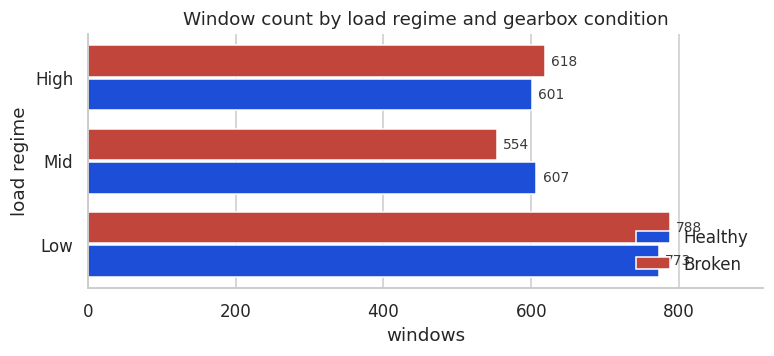

health,Broken,Healthy
regime,,
Low,788,773
Mid,554,607
High,618,601


In [3]:
counts = (data.groupby(["regime", "health"]).size()
              .unstack("health")
              .reindex(REGIME_ORDER))

fig, ax = plt.subplots(figsize=(7.2, 3.4))
y = np.arange(len(counts))
height = 0.38
gap = 0.02   # 2px-equivalent surface gap between adjacent bars

for offset, health in ((-height/2 - gap/2, "Healthy"), (height/2 + gap/2, "Broken")):
    bars = ax.barh(y + offset, counts[health], height=height,
                   color=HEALTH_COLOURS[health], label=health)
    ax.bar_label(bars, padding=4, fontsize=9, color="#3A3A38")

ax.set_yticks(y, counts.index)
ax.set_ylabel("load regime")
ax.set_xlabel("windows")
ax.set_xlim(0, counts.to_numpy().max() * 1.16)
ax.set_title("Window count by load regime and gearbox condition")
ax.legend(title=None, loc="lower right", frameon=False)
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

counts

Six classes, each between 554 and 788 windows. Balanced enough that plain accuracy
is a fair headline number — though MCC is still reported alongside it, because MCC
degrades honestly if any one class collapses and accuracy does not.

## 2 · What does the raw vibration actually look like?

This section needs the raw recordings. If they are not present it is skipped; the
stored outputs below were generated with them in place.

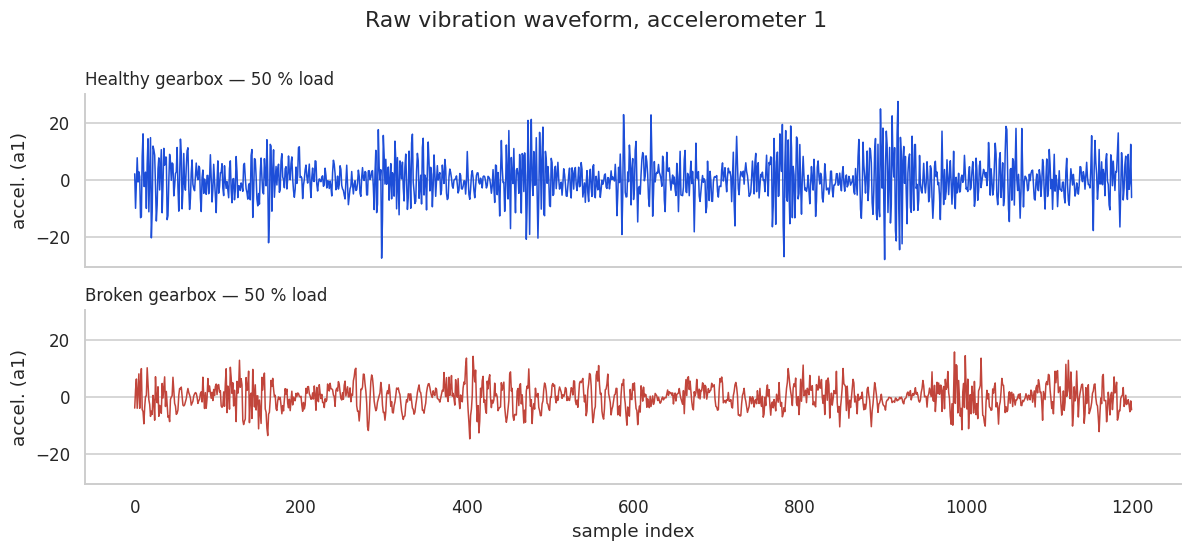

In [4]:
def load_raw(name: str, n: int = 4096) -> np.ndarray | None:
    """First `n` samples of one raw recording, as an (n, 4) array."""
    if not RAW_AVAILABLE:
        return None
    matches = list(RAW_DIR.rglob(name))
    if not matches:
        return None
    frame = pd.read_csv(matches[0], sep=r"\s+", header=None,
                        names=["a1", "a2", "a3", "a4"], engine="python",
                        skip_blank_lines=True, nrows=n + 5)
    return frame.apply(pd.to_numeric, errors="coerce").dropna().to_numpy()[:n]


healthy_raw = load_raw("h30hz50.txt")
broken_raw = load_raw("b30hz50.txt")

if healthy_raw is None:
    print("Raw recordings not found in ../data — skipping section 2.\n"
          "Download the two zips linked in README.md and unpack them there to run it.")
else:
    window = 1200          # samples, enough to show several shaft revolutions
    fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True, sharey=True)

    for ax, signal, label in ((axes[0], healthy_raw, "Healthy"),
                              (axes[1], broken_raw, "Broken")):
        ax.plot(signal[:window, 0], lw=1.0, color=HEALTH_COLOURS[label])
        ax.set_ylabel("accel. (a1)")
        ax.set_title(f"{label} gearbox — 50 % load", loc="left", fontsize=11)
        ax.grid(axis="x", visible=False)

    axes[1].set_xlabel("sample index")
    fig.suptitle("Raw vibration waveform, accelerometer 1", y=1.0)
    plt.tight_layout(); plt.show()

The damaged gearbox is not the noisier of the two — the healthy trace swings
wider. That is the opposite of the textbook expectation, and it is the single most
important thing in this dataset.

The explanation is not mechanical. The healthy and broken-tooth recordings were
captured in **separate acquisition campaigns**, and the sensor mounting or gain
evidently differed between them. Any classifier handed these two sets will lock onto
the amplitude offset rather than onto anything about the gear teeth.

Section 3 quantifies exactly how large that offset is.

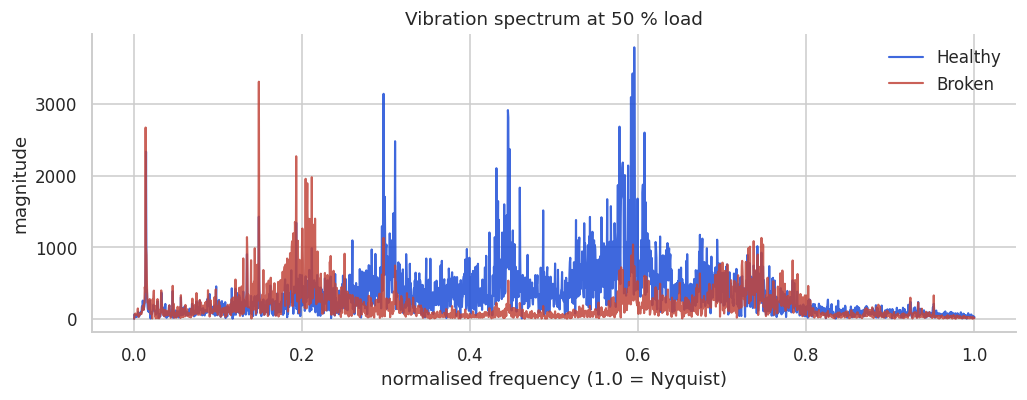

In [5]:
if healthy_raw is not None:
    fig, ax = plt.subplots(figsize=(9.5, 3.8))

    for signal, label in ((healthy_raw, "Healthy"), (broken_raw, "Broken")):
        centred = signal[:, 0] - signal[:, 0].mean()
        spectrum = np.abs(np.fft.rfft(centred))
        freq = np.linspace(0, 1, spectrum.size)   # normalised: 1.0 = Nyquist
        ax.plot(freq, spectrum, lw=1.4, alpha=0.85,
                color=HEALTH_COLOURS[label], label=label)

    ax.set_xlabel("normalised frequency (1.0 = Nyquist)")
    ax.set_ylabel("magnitude")
    ax.set_title("Vibration spectrum at 50 % load")
    ax.legend(frameon=False)
    plt.tight_layout(); plt.show()

Frequencies are normalised to Nyquist rather than shown in Hz, because the
vendor never published the sampling rate for this dataset. Both spectra are
broadband with energy concentrated low; the damaged gearbox carries relatively more
high-frequency content, which is what the `hf_ratio` and `spec_centroid` descriptors
are designed to capture.

## 3 · The amplitude artefact, quantified

Plotting mean RMS against load for each condition shows how cleanly separated the
two campaigns are.

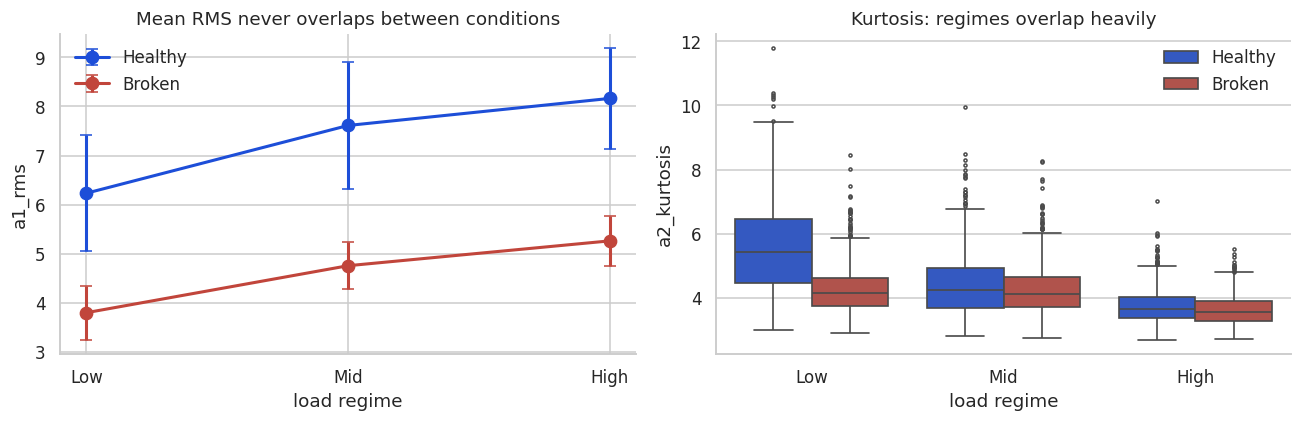

regime,Low,Mid,High
health,,,
Broken,3.80,4.75,5.26
Healthy,6.23,7.61,8.16


In [6]:
rms_by_load = (data.groupby(["regime", "health"])["a1_rms"]
                   .agg(["mean", "std"])
                   .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- left: mean +/- 1 sd, by regime
for health in ("Healthy", "Broken"):
    subset = (rms_by_load[rms_by_load.health == health]
              .set_index("regime").reindex(REGIME_ORDER).reset_index())
    axes[0].errorbar(REGIME_ORDER, subset["mean"], yerr=subset["std"],
                     marker="o", markersize=8, lw=2, capsize=4,
                     color=HEALTH_COLOURS[health], label=health)
axes[0].set_xlabel("load regime"); axes[0].set_ylabel("a1_rms")
axes[0].set_title("Mean RMS never overlaps between conditions")
axes[0].legend(frameon=False)

# --- right: the descriptor where the regimes DO overlap
sns.boxplot(data=data, x="regime", y="a2_kurtosis", hue="health",
            order=REGIME_ORDER, hue_order=["Healthy", "Broken"],
            palette=HEALTH_COLOURS, fliersize=2, linewidth=1.1, ax=axes[1])
axes[1].set_xlabel("load regime"); axes[1].set_ylabel("a2_kurtosis")
axes[1].set_title("Kurtosis: regimes overlap heavily")
axes[1].legend(frameon=False, title=None)

plt.tight_layout(); plt.show()

data.groupby(["health", "regime"])["a1_rms"].mean().unstack()[REGIME_ORDER].round(2)

**Consequence for the modelling.** The left panel is why plain
*healthy vs broken* classification is worthless as a comparison task here: a single
threshold on `a1_rms` separates the classes at every load, and all six models score
~100 %. A table of six identical `1.0000` rows ranks nothing.

The right panel is where the real difficulty lives — telling the **load regimes**
apart. That is why the modelling target combines both: `Healthy-Low`, `Healthy-Mid`,
… `Broken-High`. The health half is nearly free; the load half is genuinely hard,
and it is what separates the six models.

## 4 · Which descriptors carry signal, and which are redundant?

Two questions here. First, how much does each descriptor tell us about the
six-class label? Second, how much of that is the *same* information counted twice?

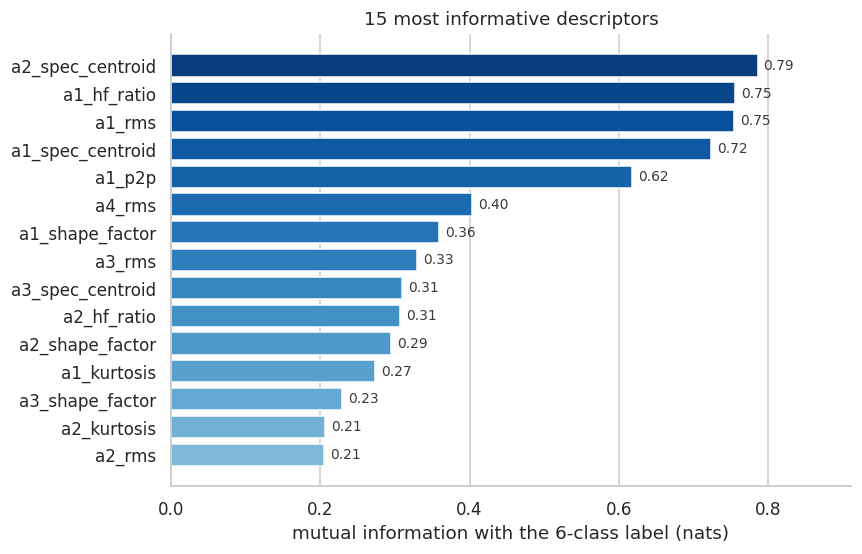

,mean MI across the 4 channels
spec_centroid,0.483
rms,0.423
hf_ratio,0.283
p2p,0.264
shape_factor,0.256
kurtosis,0.213
impulse_factor,0.135
crest_factor,0.093
skewness,0.082


In [7]:
from sklearn.feature_selection import mutual_info_classif

mi = pd.Series(
    mutual_info_classif(data[features], data[TARGET], random_state=17),
    index=features, name="mutual information").sort_values(ascending=False)

top = mi.head(15).sort_values()

fig, ax = plt.subplots(figsize=(8, 5.2))
# Magnitude, not identity -> one hue, light to dark, never categorical colours.
shades = plt.cm.Blues(np.linspace(0.45, 0.95, len(top)))
bars = ax.barh(top.index, top.to_numpy(), color=shades)
ax.bar_label(bars, fmt="%.2f", padding=4, fontsize=9, color="#3A3A38")
ax.set_xlabel("mutual information with the 6-class label (nats)")
ax.set_xlim(0, top.max() * 1.16)
ax.set_title("15 most informative descriptors")
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

mi.groupby(mi.index.str.split("_").str[1:].str.join("_")).mean() \
  .sort_values(ascending=False).round(3).to_frame("mean MI across the 4 channels")

`rms` and `p2p` dominate — both are amplitude measures, and section 3 showed
amplitude is doing most of the work. The dimensionless ratios (`crest_factor`,
`shape_factor`, `impulse_factor`) and the spectral descriptors contribute less
individually but are what remain when amplitude is uninformative.

Now the redundancy question.

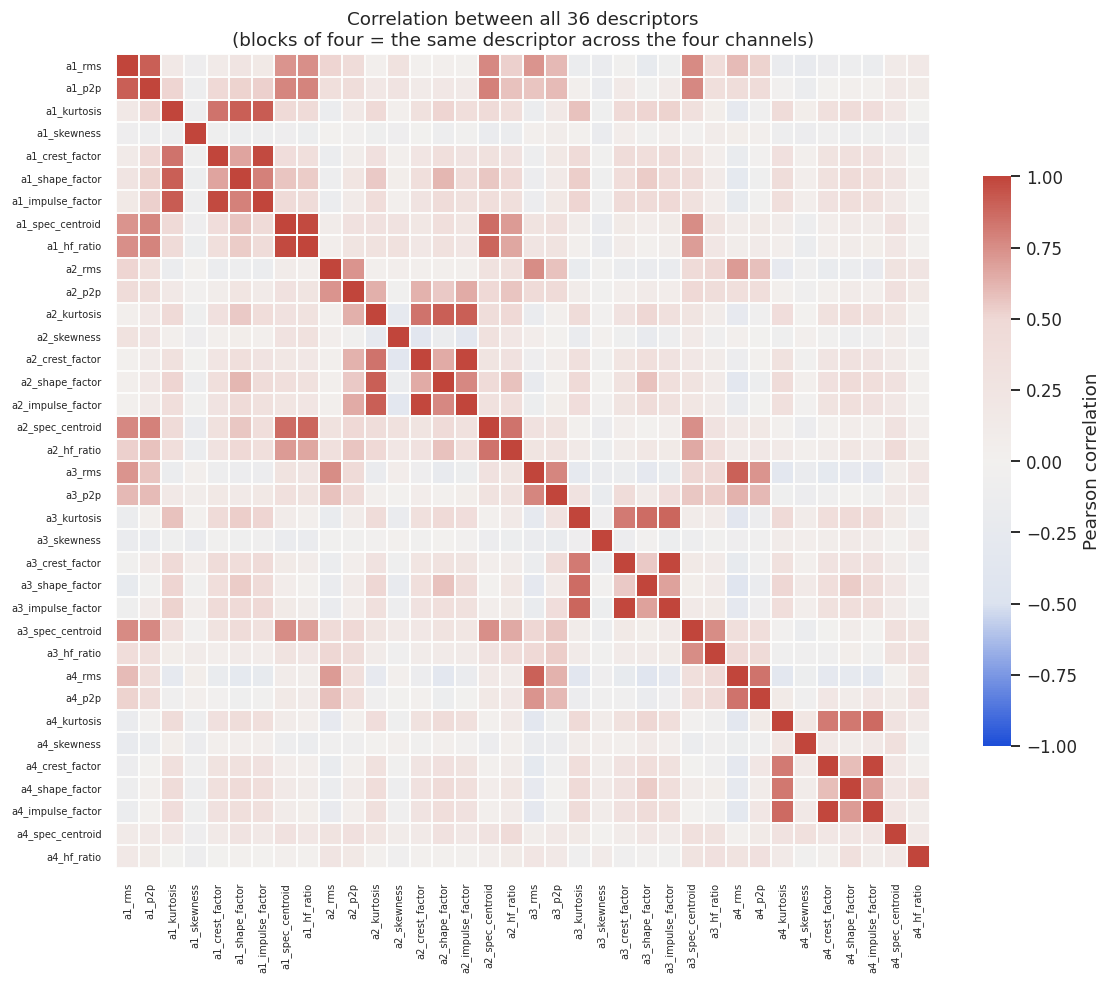

In [8]:
corr = data[features].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap=DIVERGING, vmin=-1, vmax=1, center=0, square=True,
            linewidths=0.3, linecolor="#FCFCFB",
            cbar_kws={"label": "Pearson correlation", "shrink": 0.7}, ax=ax)
ax.set_title("Correlation between all 36 descriptors\n"
             "(blocks of four = the same descriptor across the four channels)")
ax.tick_params(labelsize=6.5)
plt.tight_layout(); plt.show()

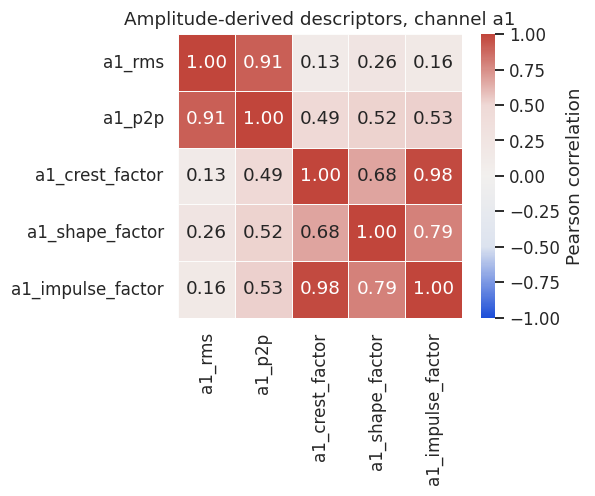

pairs correlated above |0.8| within this block: 2


In [9]:
# The five descriptors below are all built from the same two quantities --
# the window's peak and its mean absolute value -- so they cannot be independent.
related = ["a1_rms", "a1_p2p", "a1_crest_factor", "a1_shape_factor", "a1_impulse_factor"]
block = data[related].corr().round(3)

fig, ax = plt.subplots(figsize=(5.6, 4.6))
sns.heatmap(block, cmap=DIVERGING, vmin=-1, vmax=1, center=0, annot=True, fmt=".2f",
            square=True, linewidths=0.5, linecolor="#FCFCFB",
            cbar_kws={"label": "Pearson correlation"}, ax=ax)
ax.set_title("Amplitude-derived descriptors, channel a1")
plt.tight_layout(); plt.show()

strong = (block.where(~np.eye(len(block), dtype=bool)).abs() > 0.8).sum().sum() // 2
print(f"pairs correlated above |0.8| within this block: {strong}")

**Consequence for the modelling.** `crest_factor` and `impulse_factor` correlate
at **0.98** — they share the same peak numerator, differing only in whether they
divide by RMS or by mean absolute value. `rms` and `p2p` sit at **0.91**, and
`shape_factor` tracks `impulse_factor` at **0.79**. Gaussian Naive Bayes assumes
the features are conditionally independent given the class, so it effectively counts
this one piece of evidence several times over and its posteriors come out
miscalibrated.

That is visible in the results as a specific signature: Naive Bayes scores a strong
**AUC of 0.9704** but only **0.7988 accuracy**. It orders the windows sensibly and
then puts the decision boundary in the wrong place — exactly what over-counted
evidence does.

## 5 · Is the six-class structure separable?

A two-component PCA of the standardised features. Colour carries the gearbox
condition and marker shape carries the load regime, so the two facts are encoded
separately rather than as six arbitrary hues — and neither depends on colour alone.

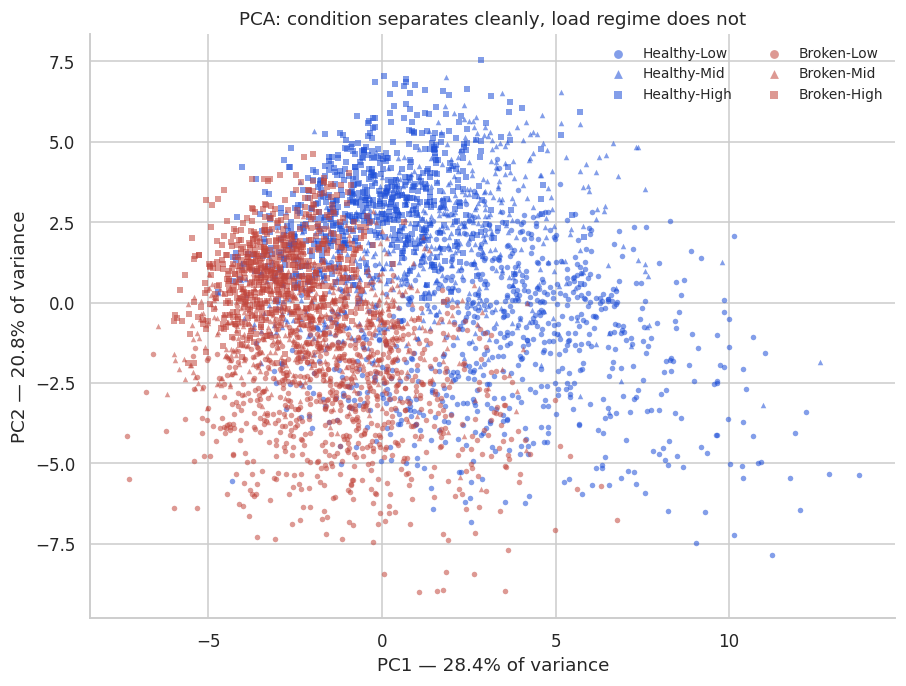

variance captured by the first two components: 49.2%


In [10]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaled = StandardScaler().fit_transform(data[features])
pca = PCA(n_components=2, random_state=17)
coords = pca.fit_transform(scaled)

projected = pd.DataFrame(coords, columns=["PC1", "PC2"])
projected["health"] = data["health"].to_numpy()
projected["regime"] = data["regime"].to_numpy()

fig, ax = plt.subplots(figsize=(8.4, 6.4))
markers = {"Low": "o", "Mid": "^", "High": "s"}

for health in ("Healthy", "Broken"):
    for regime in REGIME_ORDER:
        subset = projected[(projected.health == health) & (projected.regime == regime)]
        ax.scatter(subset.PC1, subset.PC2, s=13, alpha=0.55,
                   c=HEALTH_COLOURS[health], marker=markers[regime],
                   linewidths=0, label=f"{health}-{regime}")

var = pca.explained_variance_ratio_
ax.set_xlabel(f"PC1 — {var[0]:.1%} of variance")
ax.set_ylabel(f"PC2 — {var[1]:.1%} of variance")
ax.set_title("PCA: condition separates cleanly, load regime does not")
ax.legend(frameon=False, fontsize=9, ncol=2, markerscale=1.6)
plt.tight_layout(); plt.show()

print(f"variance captured by the first two components: {var.sum():.1%}")

Two things stand out.

**The colours form two broad groups**, but only two components are shown here and
they carry 49.2 % of the variance between them, so there is visible mixing around
the middle. The separation is real but this projection understates it — the cell
below measures how much is lost by compressing to 2D.

**The marker shapes do not group.** Within each colour the three load regimes lie
along a gradient — high load toward the upper left, low load toward the lower right
— with substantial overlap at the joins. That overlap is where the classification
error ends up.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline

# How separable is each half of the label -- in the 2-D projection above, and in
# the full 36-dimensional feature space the models actually see?
rows = {}
for space, matrix in (("2 principal components", coords),
                      ("all 36 features", scaled)):
    for question, labels in (("health (Healthy vs Broken)", data["health"]),
                             ("load regime (Low/Mid/High)", data["regime"]),
                             ("full 6-class label", data[TARGET])):
        score = cross_val_score(
            make_pipeline(LogisticRegression(max_iter=5000)),
            matrix, labels, cv=5, scoring="accuracy").mean()
        rows.setdefault(question, {})[space] = round(score, 4)

pd.DataFrame(rows).T

,2 principal components,all 36 features
health (Healthy vs Broken),0.8320,1.0000
load regime (Low/Mid/High),0.7216,0.8544
full 6-class label,0.5983,0.8820


This is the whole story in one table, and it corrects the impression the scatter
plot gives.

**In the full 36-dimensional space the health question is already solved** — 1.0000,
a perfect score. The load regime sits at 0.8544, and that gap is the entire
difficulty of this dataset. Everything the six classifiers compete over in
`gearbox_models.ipynb` is the regime half of the label.

**The 2-D projection degrades everything, health most of all** (1.0000 → 0.8320).
So the mixing visible in the scatter above is an artefact of compressing 36
dimensions into 2, not evidence that the conditions genuinely overlap. Read the
scatter for the *shape* of the class structure, not for how separable it is.

One detail worth noticing: the six-class score (0.8820) is *higher* than the
regime-only score (0.8544), even though getting the six-class label right requires
getting the regime right as well. Training on the joint label lets the model learn a
**different regime boundary for each condition** — and since the two conditions were
recorded in separate campaigns with different amplitude scales, that is exactly the
right thing to do.

*(These are 5-fold cross-validation scores over the pooled data, used here only to
compare the two feature spaces. The headline results in the modelling notebook use
the stricter chronological split, so the numbers are not directly comparable.)*

The models later confirm the main point numerically: out of 1,188 test windows, the
number of predictions that cross the healthy/damaged boundary is **zero or one** for
every one of the six classifiers. All residual error is load-regime confusion.

In [12]:
# How much of a single feature's variation is explained by regime vs by health?
from sklearn.feature_selection import f_classif

f_health, _ = f_classif(data[features], data["health"])
f_regime, _ = f_classif(data[features], data["regime"])

separability = (pd.DataFrame({"health": f_health, "regime": f_regime}, index=features)
                  .groupby(lambda c: c.split("_", 1)[1]).mean()
                  .sort_values("regime", ascending=False).round(1))
separability.index.name = "descriptor"
separability

,health,regime
descriptor,,
rms,1372.7,1148.6
shape_factor,451.0,744.7
kurtosis,301.5,565.0
impulse_factor,227.3,376.4
p2p,1639.2,277.7
crest_factor,159.5,276.8
skewness,237.5,101.6
spec_centroid,8928.3,83.7
hf_ratio,16496.4,56.3


ANOVA F-statistics per descriptor, averaged over the four channels. The `health`
column is enormous for the amplitude descriptors — the artefact again. The `regime`
column is the one that matters for the actual difficulty of the task, and it is
led by the amplitude and spectral descriptors rather than the shape ratios.

## 6 · What this told the modelling

| Observation | Where it went |
|---|---|
| Healthy and damaged recordings differ in absolute amplitude at every load | Binary health classification rejected as the target — it is saturated at ~100 % and ranks nothing |
| Load regimes overlap heavily in every descriptor | Target became the 6-class `condition × load-regime` combination, which is genuinely hard |
| `load_pct` is recoverable from the label | Excluded from the feature set entirely — keeping it would leak the regime |
| Neighbouring windows of one recording are near-duplicates | Split is chronological within each recording, not random, so near-duplicates cannot straddle train and test |
| Five descriptors share the same peak / mean-abs terms | Explains Naive Bayes' high-AUC / low-accuracy signature |
| Condition separates in 2 PCA components; regime does not | Predicts the block-diagonal confusion matrices — zero cross-boundary errors, all error in the load regime |

The modelling itself, with the comparison table for all six classifiers, is in
**`gearbox_models.ipynb`**.

---

### A note on the colours used here

The obvious palette for healthy-versus-damaged is green-versus-red. It was checked
and rejected: that pair separates by only ΔE 7.7 under deuteranopia, the most common
colour-vision deficiency, so the two conditions would be near-indistinguishable for
roughly one in twelve male readers. The blue/red pair used throughout separates by
ΔE 25.7 under protanopia and ΔE 34.2 for normal vision. In the PCA scatter, load
regime is additionally encoded by marker shape, so no distinction in this notebook
rests on colour alone.